<div style="text-align:center; markdown=1">
<span style="font-size:12pt">Tugas Proyek Mata Kuliah Kecerdasan Buatan</span><br>
<span style="font-size:14pt"><b>Prediksi Kualitas dalam Proses Penambangan</b></span><br>
Menggunakan Algoritma KNN dan Adaboost Regresor</div>

<span style="font-size:14pt"><b>Kelompok 4:</b></span><br>
   1. M. Nadhir Al Ghifary 22/503570/TK/55030
   2. Ahmad Farrel Baswara 22/493497/TK/54068
   3. Faris Afif Ridyasmara 22/502798/TK/54902

Link Dataset:
https://www.kaggle.com/datasets/edumagalhaes/quality-prediction-in-a-mining-process

In [46]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import timedelta

In [47]:
df = pd.read_csv("MiningProcess_Flotation_Plant_Database.csv")

___

### <span style="font-size:20pt"><b>#1: Telaah Data </b></span>

#### <b>A. Menampilkan Informasi Dataset</b>

In [48]:
# Menampilkan 9 baris pertama dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 737453 entries, 0 to 737452
Data columns (total 24 columns):
 #   Column                        Non-Null Count   Dtype 
---  ------                        --------------   ----- 
 0   date                          737453 non-null  object
 1   % Iron Feed                   737453 non-null  object
 2   % Silica Feed                 737453 non-null  object
 3   Starch Flow                   737453 non-null  object
 4   Amina Flow                    737453 non-null  object
 5   Ore Pulp Flow                 737453 non-null  object
 6   Ore Pulp pH                   737453 non-null  object
 7   Ore Pulp Density              737453 non-null  object
 8   Flotation Column 01 Air Flow  737453 non-null  object
 9   Flotation Column 02 Air Flow  737453 non-null  object
 10  Flotation Column 03 Air Flow  737453 non-null  object
 11  Flotation Column 04 Air Flow  737453 non-null  object
 12  Flotation Column 05 Air Flow  737453 non-null  object
 13 

#### <b>B. Menampilkan Dataset</b>

In [ ]:
#Menampilkan 5 data awal dataset
df.head(5)

,date,% Iron Feed,% Silica Feed,Starch Flow,Amina Flow,Ore Pulp Flow,Ore Pulp pH,Ore Pulp Density,Flotation Column 01 Air Flow,Flotation Column 02 Air Flow,...,Flotation Column 07 Air Flow,Flotation Column 01 Level,Flotation Column 02 Level,Flotation Column 03 Level,Flotation Column 04 Level,Flotation Column 05 Level,Flotation Column 06 Level,Flotation Column 07 Level,% Iron Concentrate,% Silica Concentrate
0,2017-03-10 01:00:00,"55,2","16,98","3019,53","557,434","395,713","10,0664","1,74","249,214","253,235",...,"250,884","457,396","432,962","424,954","443,558","502,255","446,37","523,344","66,91","1,31"
1,2017-03-10 01:00:00,"55,2","16,98","3024,41","563,965","397,383","10,0672","1,74","249,719","250,532",...,"248,994","451,891","429,56","432,939","448,086","496,363","445,922","498,075","66,91","1,31"
2,2017-03-10 01:00:00,"55,2","16,98","3043,46","568,054","399,668","10,068","1,74","249,741","247,874",...,"248,071","451,24","468,927","434,61","449,688","484,411","447,826","458,567","66,91","1,31"
3,2017-03-10 01:00:00,"55,2","16,98","3047,36","568,665","397,939","10,0689","1,74","249,917","254,487",...,"251,147","452,441","458,165","442,865","446,21","471,411","437,69","427,669","66,91","1,31"
4,2017-03-10 01:00:00,"55,2","16,98","3033,69","558,167","400,254","10,0697","1,74","250,203","252,136",...,"248,928","452,441","452,9","450,523","453,67","462,598","443,682","425,679","66,91","1,31"


In [ ]:
#Menampilkan 5 data terakhir dataset
df.tail(5)

,date,% Iron Feed,% Silica Feed,Starch Flow,Amina Flow,Ore Pulp Flow,Ore Pulp pH,Ore Pulp Density,Flotation Column 01 Air Flow,Flotation Column 02 Air Flow,...,Flotation Column 07 Air Flow,Flotation Column 01 Level,Flotation Column 02 Level,Flotation Column 03 Level,Flotation Column 04 Level,Flotation Column 05 Level,Flotation Column 06 Level,Flotation Column 07 Level,% Iron Concentrate,% Silica Concentrate
737448,2017-09-09 23:00:00,"49,75","23,2","2710,94","441,052","386,57","9,62129","1,65365","302,344","298,786",...,"313,695","392,16","430,702","872,008","418,725","497,548","446,357","416,892","64,27","1,71"
737449,2017-09-09 23:00:00,"49,75","23,2","2692,01","473,436","384,939","9,62063","1,65352","303,013","301,879",...,"236,7","401,505","404,616","864,409","418,377","506,398","372,995","426,337","64,27","1,71"
737450,2017-09-09 23:00:00,"49,75","23,2","2692,2","500,488","383,496","9,61874","1,65338","303,662","307,397",...,"225,879","408,899","399,316","867,598","419,531","503,414","336,035","433,13","64,27","1,71"
737451,2017-09-09 23:00:00,"49,75","23,2","1164,12","491,548","384,976","9,61686","1,65324","302,55","301,959",...,"308,115","405,107","466,832","876,591","407,299","502,301","340,844","433,966","64,27","1,71"
737452,2017-09-09 23:00:00,"49,75","23,2","1164,12","468,019","384,801","9,61497","1,6531","300,355","292,865",...,"308,115","413,754","514,143","881,323","378,969","500,1","374,354","441,182","64,27","1,71"


Berdasarkan telaah data tersebut, diperlukan perbaikan data sebelum visualiasi dan analisis statistik karena:
1. Seluruh nilai tiap variabel bertipe `object`.
2. Kolom date masih bernilai sama untuk 180 kolom sedangkan seharusnya terdapat selisih 20 detik tiap baris

___

### <span style="font-size:20pt"><b>#2: Perbaikan Data </b></span>

#### <b>A. Merubah Tipe Variabel dari Object ke Float</b>

In [51]:
# Ubah kolom tanggal bertipe object menjadi datetime
df['date'] = pd.to_datetime(df['date'], format='%Y-%m-%d %H:%M:%S')

# Ubah kolom bertipe object yang masih tersisa menjadi float
for col in df.select_dtypes(include='object').columns:
    df[col] = df[col].str.replace(',', '.')
    df[col] = pd.to_numeric(df[col], errors='coerce')

In [52]:
# Menampilkan Informasi Singkat dari Dataset setelah perubahan tipe variabel
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 737453 entries, 0 to 737452
Data columns (total 24 columns):
 #   Column                        Non-Null Count   Dtype         
---  ------                        --------------   -----         
 0   date                          737453 non-null  datetime64[ns]
 1   % Iron Feed                   737453 non-null  float64       
 2   % Silica Feed                 737453 non-null  float64       
 3   Starch Flow                   737453 non-null  float64       
 4   Amina Flow                    737453 non-null  float64       
 5   Ore Pulp Flow                 737453 non-null  float64       
 6   Ore Pulp pH                   737453 non-null  float64       
 7   Ore Pulp Density              737453 non-null  float64       
 8   Flotation Column 01 Air Flow  737453 non-null  float64       
 9   Flotation Column 02 Air Flow  737453 non-null  float64       
 10  Flotation Column 03 Air Flow  737453 non-null  float64       
 11  Flotation Col

#### <b>B. Mengubah Nilai Kolom Date Menjadi Selisih 20 Detik Tiap Baris </b>

In [53]:
# Konversi kolom 'date' menjadi tipe datetime
df['date'] = pd.to_datetime(df['date'])

# Atur waktu awal untuk baris pertama (1:01:40)
start_time = pd.Timestamp('2017-03-10 01:01:40')

# Tambahkan selisih waktu 20 detik untuk setiap baris
df['date'] = [start_time + timedelta(seconds=20 * i) for i in range(len(df))]

In [54]:
df.head(5)

,date,% Iron Feed,% Silica Feed,Starch Flow,Amina Flow,Ore Pulp Flow,Ore Pulp pH,Ore Pulp Density,Flotation Column 01 Air Flow,Flotation Column 02 Air Flow,...,Flotation Column 07 Air Flow,Flotation Column 01 Level,Flotation Column 02 Level,Flotation Column 03 Level,Flotation Column 04 Level,Flotation Column 05 Level,Flotation Column 06 Level,Flotation Column 07 Level,% Iron Concentrate,% Silica Concentrate
0,2017-03-10 01:01:40,55.2,16.98,3019.53,557.434,395.713,10.0664,1.74,249.214,253.235,...,250.884,457.396,432.962,424.954,443.558,502.255,446.370,523.344,66.91,1.31
1,2017-03-10 01:02:00,55.2,16.98,3024.41,563.965,397.383,10.0672,1.74,249.719,250.532,...,248.994,451.891,429.560,432.939,448.086,496.363,445.922,498.075,66.91,1.31
2,2017-03-10 01:02:20,55.2,16.98,3043.46,568.054,399.668,10.0680,1.74,249.741,247.874,...,248.071,451.240,468.927,434.610,449.688,484.411,447.826,458.567,66.91,1.31
3,2017-03-10 01:02:40,55.2,16.98,3047.36,568.665,397.939,10.0689,1.74,249.917,254.487,...,251.147,452.441,458.165,442.865,446.210,471.411,437.690,427.669,66.91,1.31
4,2017-03-10 01:03:00,55.2,16.98,3033.69,558.167,400.254,10.0697,1.74,250.203,252.136,...,248.928,452.441,452.900,450.523,453.670,462.598,443.682,425.679,66.91,1.31


___

### <span style="font-size:20pt"><b>#3: Analisis Statistik Data </b></span>

#### <b>A. Menguji Kekosongan Data</b>

In [55]:
# Menghitung persentase hilang tiap parameter dataset
persentase_datahilang = (df.isnull().sum() / len(df)) * 100

# Menampilkan persentae data hilang tiap parameter dataset
print('Persentase Data Hilang')
persentase_datahilang

Persentase Data Hilang


date                            0.0
% Iron Feed                     0.0
% Silica Feed                   0.0
Starch Flow                     0.0
Amina Flow                      0.0
Ore Pulp Flow                   0.0
Ore Pulp pH                     0.0
Ore Pulp Density                0.0
Flotation Column 01 Air Flow    0.0
Flotation Column 02 Air Flow    0.0
Flotation Column 03 Air Flow    0.0
Flotation Column 04 Air Flow    0.0
Flotation Column 05 Air Flow    0.0
Flotation Column 06 Air Flow    0.0
Flotation Column 07 Air Flow    0.0
Flotation Column 01 Level       0.0
Flotation Column 02 Level       0.0
Flotation Column 03 Level       0.0
Flotation Column 04 Level       0.0
Flotation Column 05 Level       0.0
Flotation Column 06 Level       0.0
Flotation Column 07 Level       0.0
% Iron Concentrate              0.0
% Silica Concentrate            0.0
dtype: float64

#### <b>B. Analisis Statistik</b>

In [56]:
# Mengeksplorasi data
df.describe()

,date,% Iron Feed,% Silica Feed,Starch Flow,Amina Flow,Ore Pulp Flow,Ore Pulp pH,Ore Pulp Density,Flotation Column 01 Air Flow,Flotation Column 02 Air Flow,...,Flotation Column 07 Air Flow,Flotation Column 01 Level,Flotation Column 02 Level,Flotation Column 03 Level,Flotation Column 04 Level,Flotation Column 05 Level,Flotation Column 06 Level,Flotation Column 07 Level,% Iron Concentrate,% Silica Concentrate
count,737453,737453.000000,737453.000000,737453.000000,737453.000000,737453.000000,737453.000000,737453.000000,737453.000000,737453.000000,...,737453.000000,737453.000000,737453.000000,737453.000000,737453.000000,737453.000000,737453.000000,737453.000000,737453.000000,737453.000000
mean,2017-06-03 09:30:20.000002816,56.294739,14.651716,2869.140569,488.144697,397.578372,9.767639,1.680380,280.151856,277.159965,...,290.754856,520.244823,522.649555,531.352662,420.320973,425.251706,429.941018,421.021231,65.050068,2.326763
min,2017-03-10 01:01:40,42.740000,1.310000,0.002026,241.669000,376.249000,8.753340,1.519820,175.510000,175.156000,...,185.962000,149.218000,210.752000,126.255000,162.201000,166.991000,155.841000,175.349000,62.050000,0.600000
25%,2017-04-21 17:16:00,52.670000,8.940000,2076.320000,431.796000,394.264000,9.527360,1.647310,250.281000,250.457000,...,256.302000,416.978000,441.883000,411.325000,356.679000,357.653000,358.497000,356.772000,64.370000,1.440000
50%,2017-06-03 09:30:20,56.080000,13.850000,3018.430000,504.393000,399.249000,9.798100,1.697600,299.344000,296.223000,...,299.011000,491.878000,495.956000,494.318000,411.974000,408.773000,424.664575,411.065000,65.210000,2.000000
75%,2017-07-16 01:44:40,59.720000,19.600000,3727.730000,553.257000,402.968000,10.038000,1.728330,300.149000,300.690000,...,301.904000,594.114000,595.464000,601.249000,485.549000,484.329000,492.684000,476.465000,65.860000,3.010000
max,2017-08-27 17:59:00,65.780000,33.400000,6300.230000,739.538000,418.641000,10.808100,1.853250,373.871000,375.992000,...,371.593000,862.274000,828.919000,886.822000,680.359000,675.644000,698.861000,659.902000,68.010000,5.530000
std,NaN,5.157744,6.807439,1215.203734,91.230534,9.699785,0.387007,0.069249,29.621288,30.149357,...,28.670105,131.014924,128.165050,150.842164,91.794432,84.535822,89.862225,84.891491,1.118645,1.125554


#### <b>C. Korelasi Antar Variabel</b>

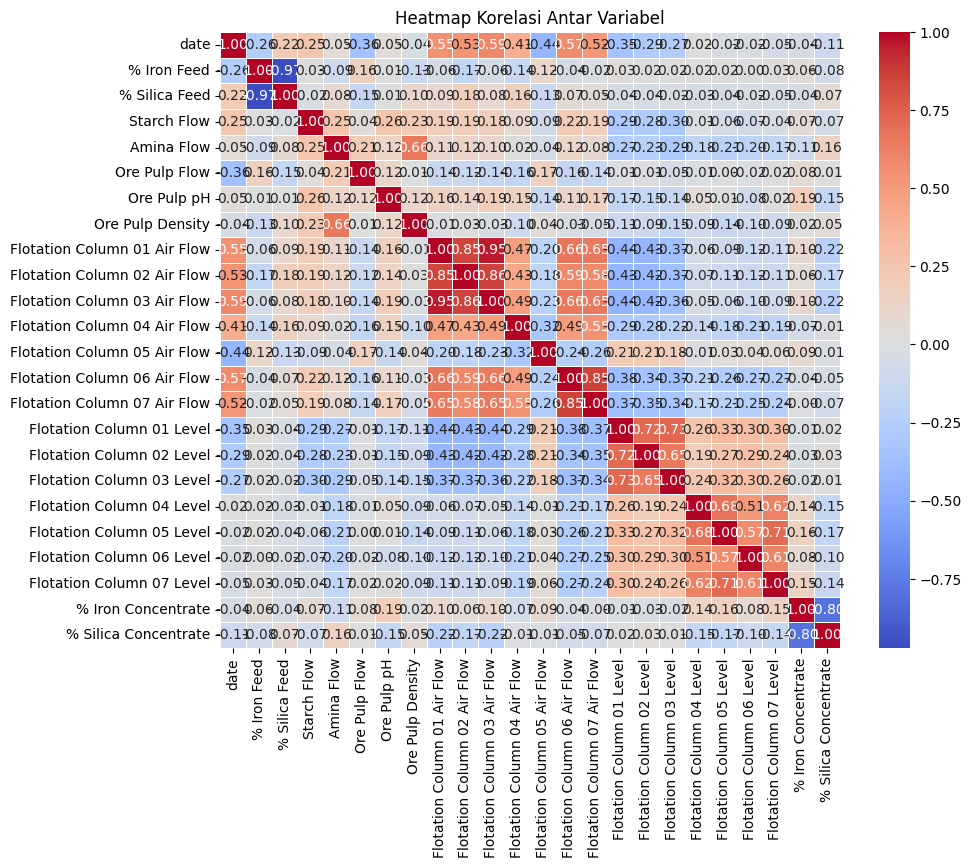

In [57]:
# Hitung matriks korelasi
correlation_matrix = df.corr()

# Plot heatmap
plt.figure(figsize=(10, 8))  # Sesuaikan ukuran jika diperlukan
sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Heatmap Korelasi Antar Variabel")
plt.show()

___

### <b>#4: Visualisasi Data </b>

#### <b>A. Boxplot Tiap Variabel</b>

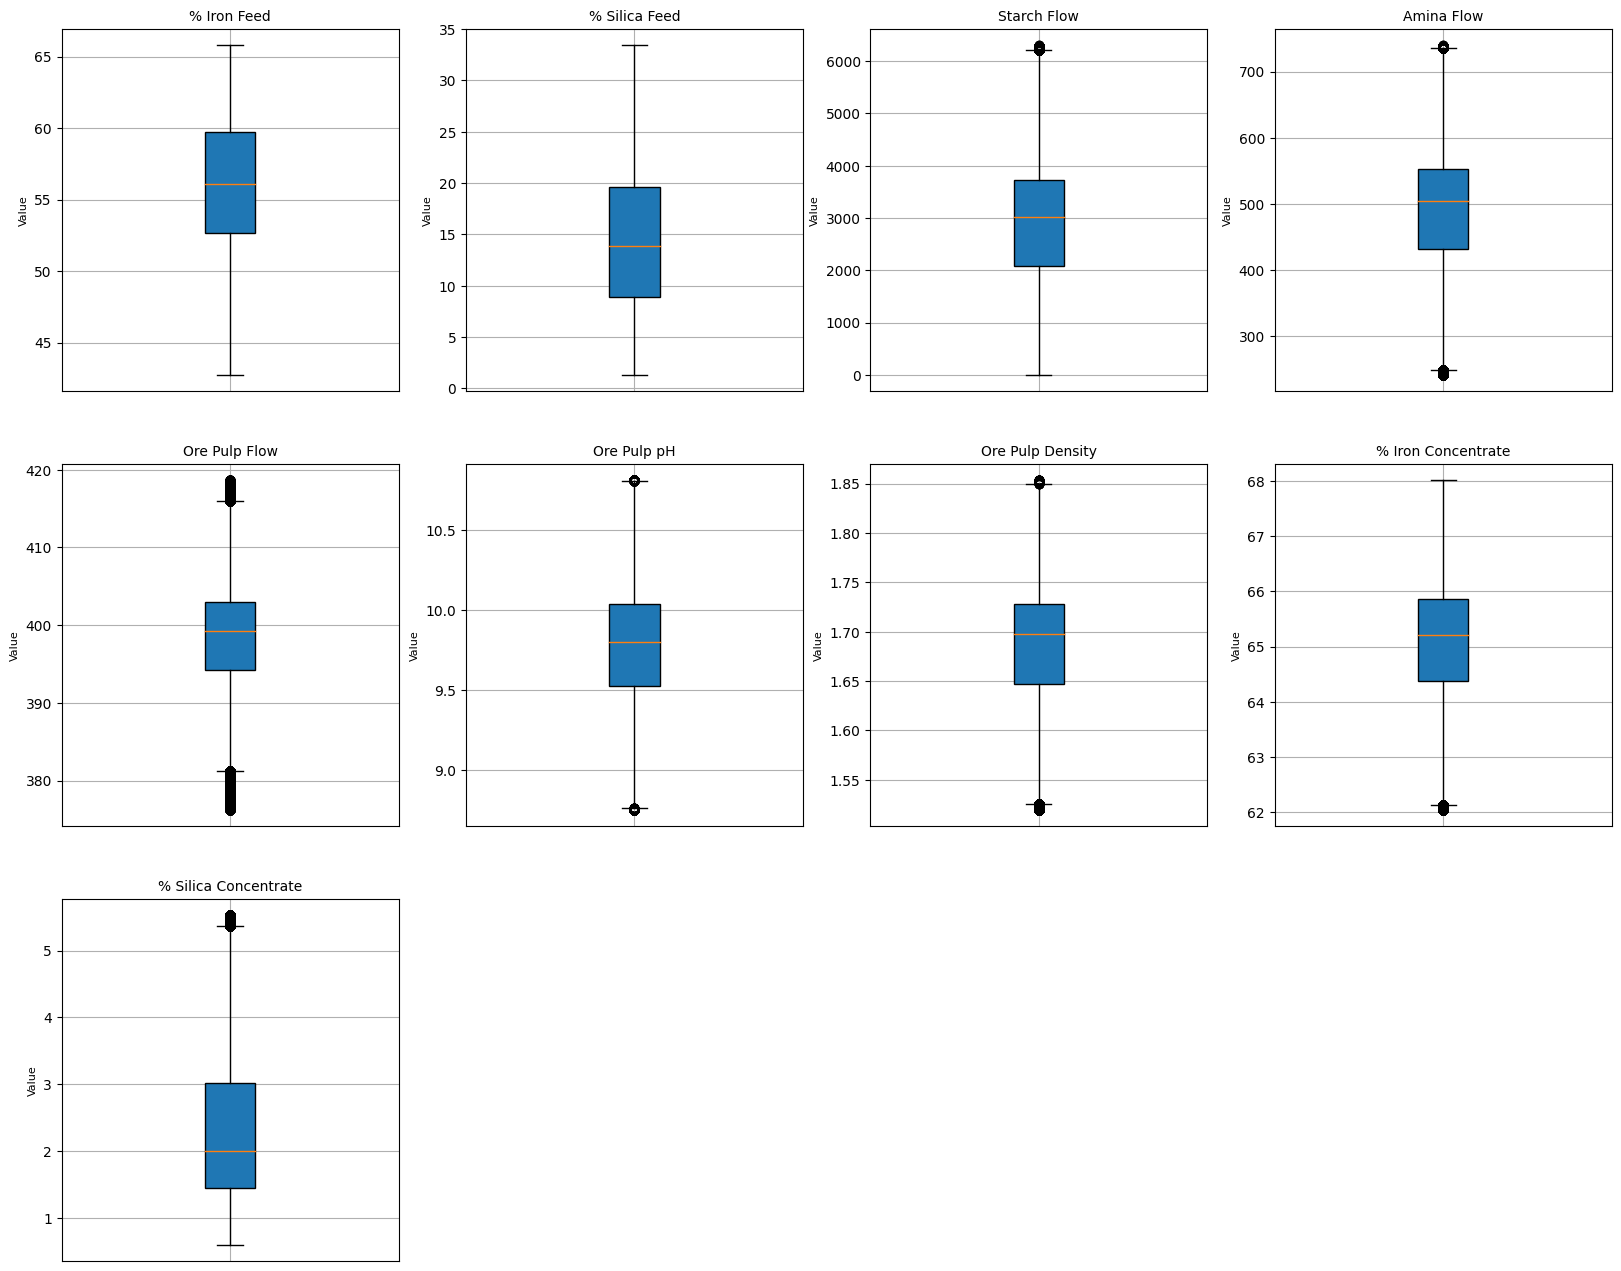

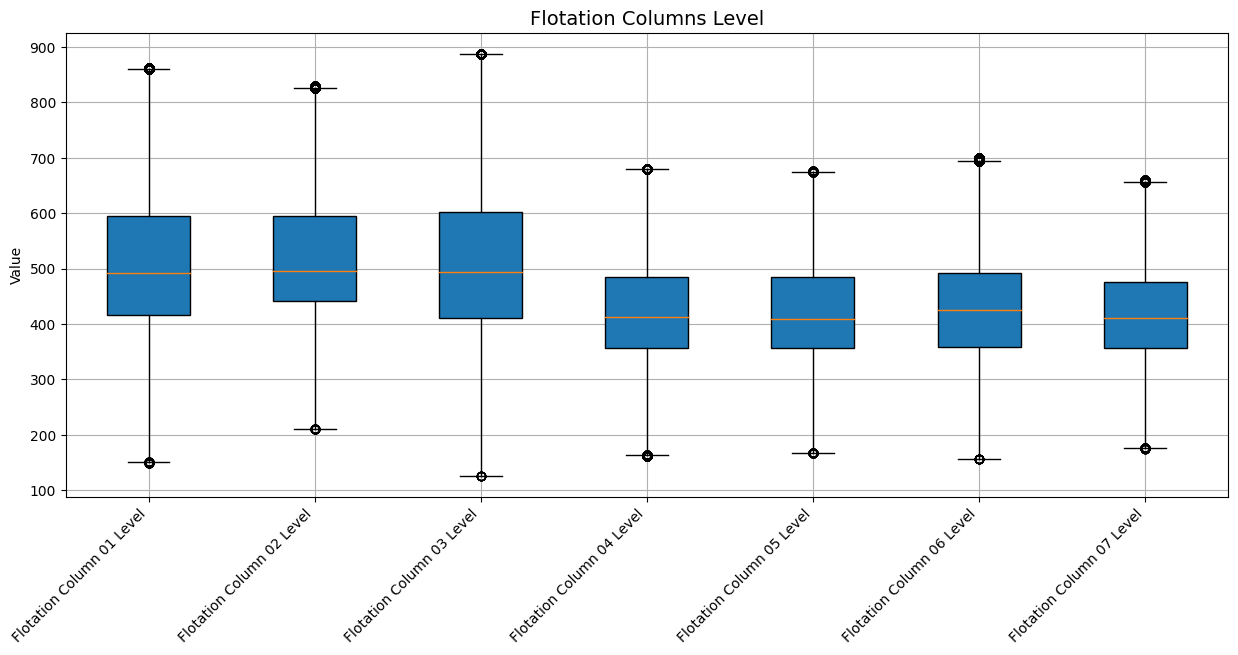

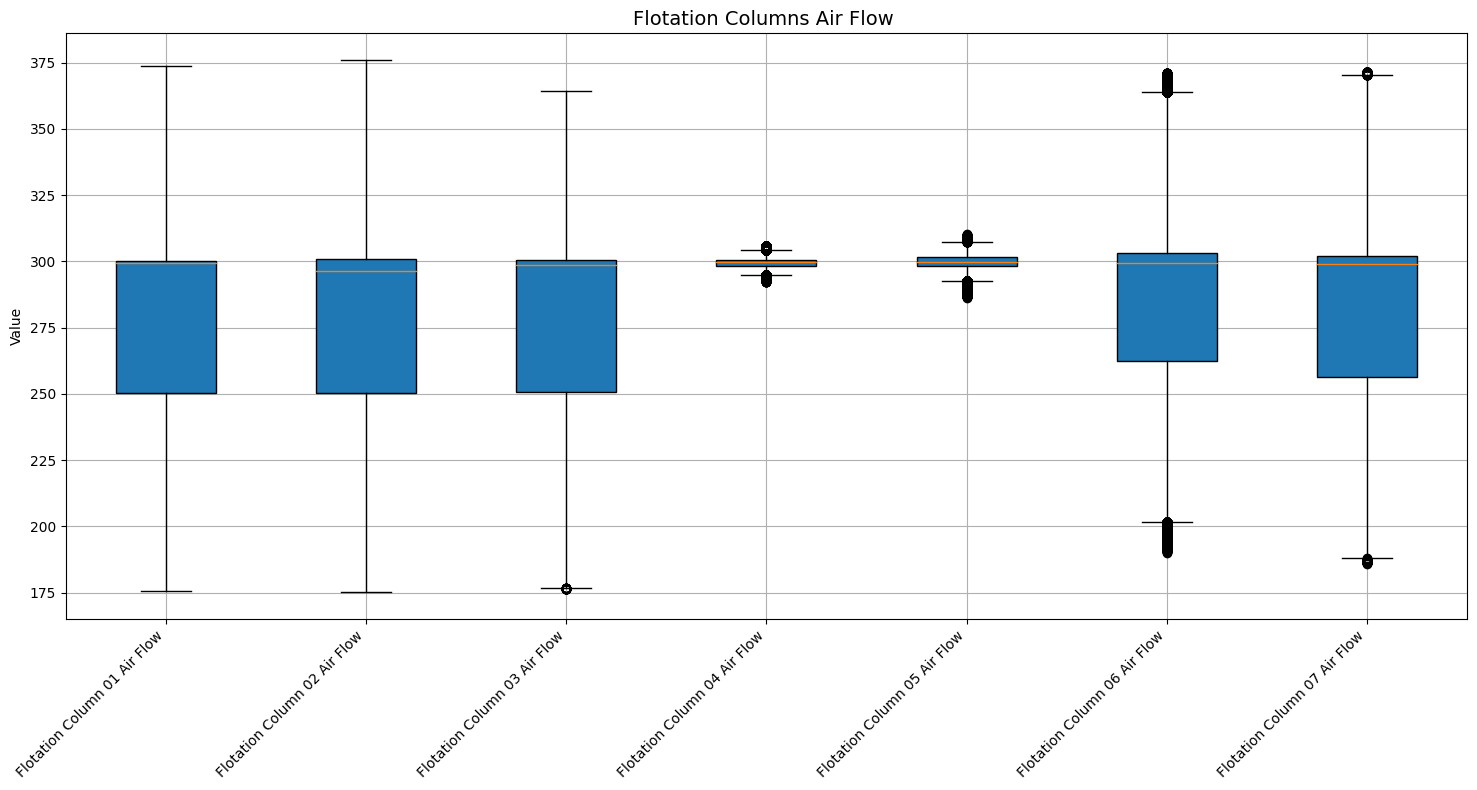

In [58]:
# Define categories for "Level" and "Air Flow"
level_columns = [col for col in df.columns if "Level" in col]
airflow_columns = [col for col in df.columns if "Air Flow" in col]

# Exclude the 'date' column and convert all relevant columns to numeric
df_numeric = df.drop(columns=["date"], errors="ignore").apply(pd.to_numeric, errors="coerce")

# Determine non-level and non-airflow columns
individual_columns = [col for col in df_numeric.columns if col not in level_columns + airflow_columns]

# Set the layout (6 rows x 4 columns) for individual columns
num_cols = 4
num_rows = (len(individual_columns) + num_cols - 1) // num_cols

fig, axes = plt.subplots(num_rows, num_cols, figsize=(20, 16))
axes = axes.flatten()  # Flatten the axes for easy iteration

# Plot individual columns
for i, col in enumerate(individual_columns):
    data = df_numeric[col].dropna()  # Drop NaN values
    axes[i].boxplot(data, patch_artist=True)
    axes[i].set_title(col, fontsize=10)
    axes[i].set_ylabel("Value", fontsize=8)
    axes[i].grid(True)
    axes[i].tick_params(axis="x", which="both", bottom=False, labelbottom=False)  # Remove x-axis values

# Add a single, wider plot for "Level" category with rotated labels
if level_columns:
    fig_level, ax_level = plt.subplots(figsize=(15, 8))  # Create a wider plot for "Level"
    level_data = [df_numeric[col].dropna() for col in level_columns]
    ax_level.boxplot(level_data, patch_artist=True, labels=level_columns)
    ax_level.set_title("Flotation Columns Level", fontsize=14)
    ax_level.set_ylabel("Value", fontsize=10)
    ax_level.grid(True)

    # Rotate x-axis labels and adjust spacing
    plt.xticks(rotation=45, ha='right', fontsize=10)  # Rotate labels 45 degrees and align right
    plt.subplots_adjust(bottom=0.3)  # Add more space at the bottom for labels

# Add a single, wider plot for "Air Flow" category with rotated labels
if airflow_columns:
    fig_airflow, ax_airflow = plt.subplots(figsize=(15, 8))  # Create a wider plot for "Air Flow"
    airflow_data = [df_numeric[col].dropna() for col in airflow_columns]
    ax_airflow.boxplot(airflow_data, patch_artist=True, labels=airflow_columns)
    ax_airflow.set_title("Flotation Columns Air Flow ", fontsize=14)
    ax_airflow.set_ylabel("Value", fontsize=10)
    ax_airflow.grid(True)

    # Rotate x-axis labels and adjust spacing
    plt.xticks(rotation=45, ha='right', fontsize=10)  # Rotate labels 45 degrees and align right
    plt.subplots_adjust(bottom=0.3)  # Add more space at the bottom for labels

# Hide any remaining empty subplots
for j in range(len(individual_columns), len(axes)):
    axes[j].axis('off')

# Adjust layout for the main figure
plt.tight_layout()

# Display all plots
plt.show()

#### <b>B. Histogram Distribusi Data Besi dan Silika Sebelum dan Sesudah Pemurnian</b>

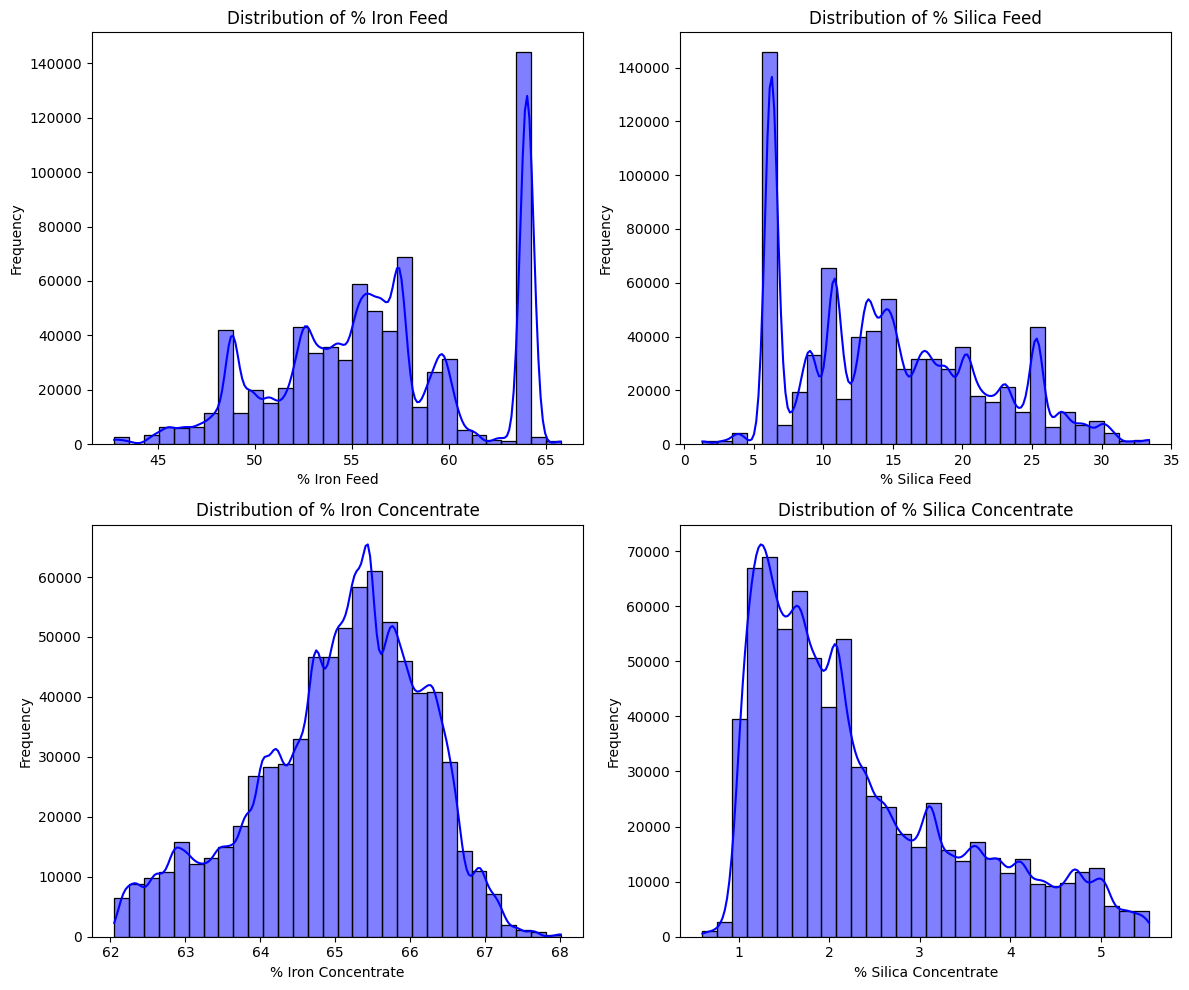

In [59]:
# Define columns to plot (choose any 4 numeric columns)
columns_to_plot = ['% Iron Feed', '% Silica Feed', '% Iron Concentrate', '% Silica Concentrate']

# Create a 2x2 layout for the plots
fig, axes = plt.subplots(2, 2, figsize=(12, 10))  # 2x2 grid

# Flatten the axes array for easy iteration
axes = axes.flatten()

# Plot each column in the 2x2 layout
for i, col in enumerate(columns_to_plot):
    sns.histplot(df_numeric[col].dropna(), kde=True, bins=30, ax=axes[i], color='blue')
    axes[i].set_title(f"Distribution of {col}", fontsize=12)
    axes[i].set_xlabel(col, fontsize=10)
    axes[i].set_ylabel("Frequency", fontsize=10)

# Adjust layout to prevent overlap
plt.tight_layout()
plt.show()

Berdasarkan histogram tersebut, nampak data outlier untuk %iron feed pada rentang nilai sekitar 63 s.d. 64 dan %silica feed pada rentang 5 s.d 7 sehingga perlu dibersihkan

#### <b>C. Tren Data Sebelum dan Sesudah Pemurnian</b>

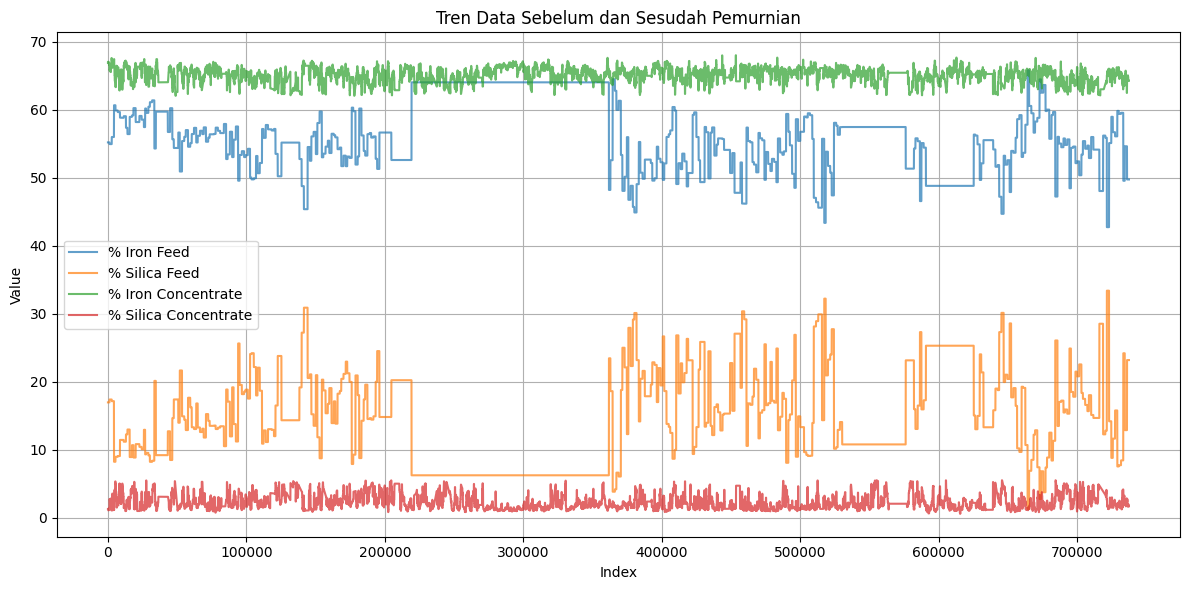

In [60]:
# Memilih kolom yang akan ditampilkan
columns_to_plot = ['% Iron Feed', '% Silica Feed', '% Iron Concentrate', '% Silica Concentrate']

# Memeriksa apakah kolom yang diperlukan ada dalam dataset
for col in columns_to_plot:
    if col not in df.columns:
        raise ValueError(f"Kolom '{col}' tidak ditemukan dalam dataset.")

# Membuat grafik tunggal
plt.figure(figsize=(12, 6))
for col in columns_to_plot:
    plt.plot(df.index, df[col], linestyle='-', label=col, alpha=0.7)

# Menambahkan judul dan label
plt.title("Tren Data Sebelum dan Sesudah Pemurnian")
plt.xlabel("Index")
plt.ylabel("Value")
plt.legend()  # Menampilkan legenda untuk setiap kolom
plt.grid(True)  # Menambahkan grid untuk memudahkan pembacaan

# Menampilkan plot
plt.tight_layout()
plt.show()

___

### <b>#5: Pre Processing Data </b>

#### <b>A. Membuang Data yang Tidak Berubah Selama 12 Jam </b>

In [16]:
# Ensure 'date' is in datetime format and sorted
df['date'] = pd.to_datetime(df['date'])
df = df.sort_values(by='date')

# Set 'date' as the index to work with time-based rolling
df.set_index('date', inplace=True)

# Calculate the rolling difference for a 5-hour period
rolling_window = df['% Iron Feed'].rolling('12h')  # 5-hour rolling window
df['iron_feed_rolling_change'] = rolling_window.apply(lambda x: x.max() - x.min(), raw=True)

# Filter out rows where the rolling change is zero
df_cleaned = df[df['iron_feed_rolling_change'] != 0].drop(columns=['iron_feed_rolling_change'])
df_cleaned = df_cleaned.where(df_cleaned.notna(), other=None)  # Ensure missing values are explicitly NaN

# Reset index if needed
df_cleaned.reset_index(inplace=True)
df.reset_index(inplace=True)
print(df_cleaned.shape[0])

457715


#### <b>B. Menampilkan Ulang Tren Data </b>

In [19]:
df['date'] = pd.to_datetime(df['date'])

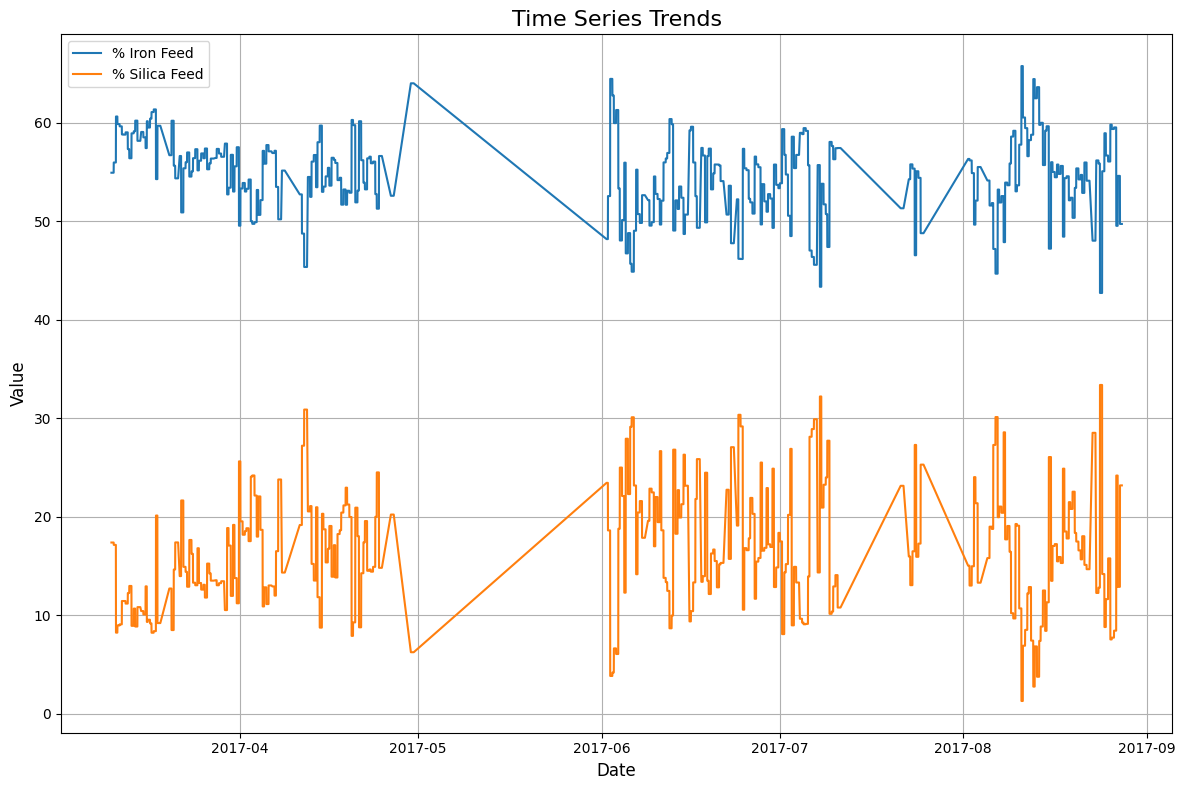

In [61]:
# Display the cleaned DataFrame
columns_to_plot = ['% Iron Feed',
                   '% Silica Feed']

# Plot time series trends
plt.figure(figsize=(12, 8))  # Adjust the figure size
for col in columns_to_plot:
    plt.plot(df_cleaned['date'], df_cleaned[col], label=col)  # Plot each column

# Add labels and legend
plt.title("Time Series Trends", fontsize=16)
plt.xlabel("Date", fontsize=12)
plt.ylabel("Value", fontsize=12)
plt.legend(loc="upper left", fontsize=10)
plt.grid(True)

# Display the plot
plt.tight_layout()
plt.show()

#### <b>C. Menampilkan Ulang Histogram Distribusi Data Besi dan Silika Sebelum dan Sesudah Pemurnian</b>

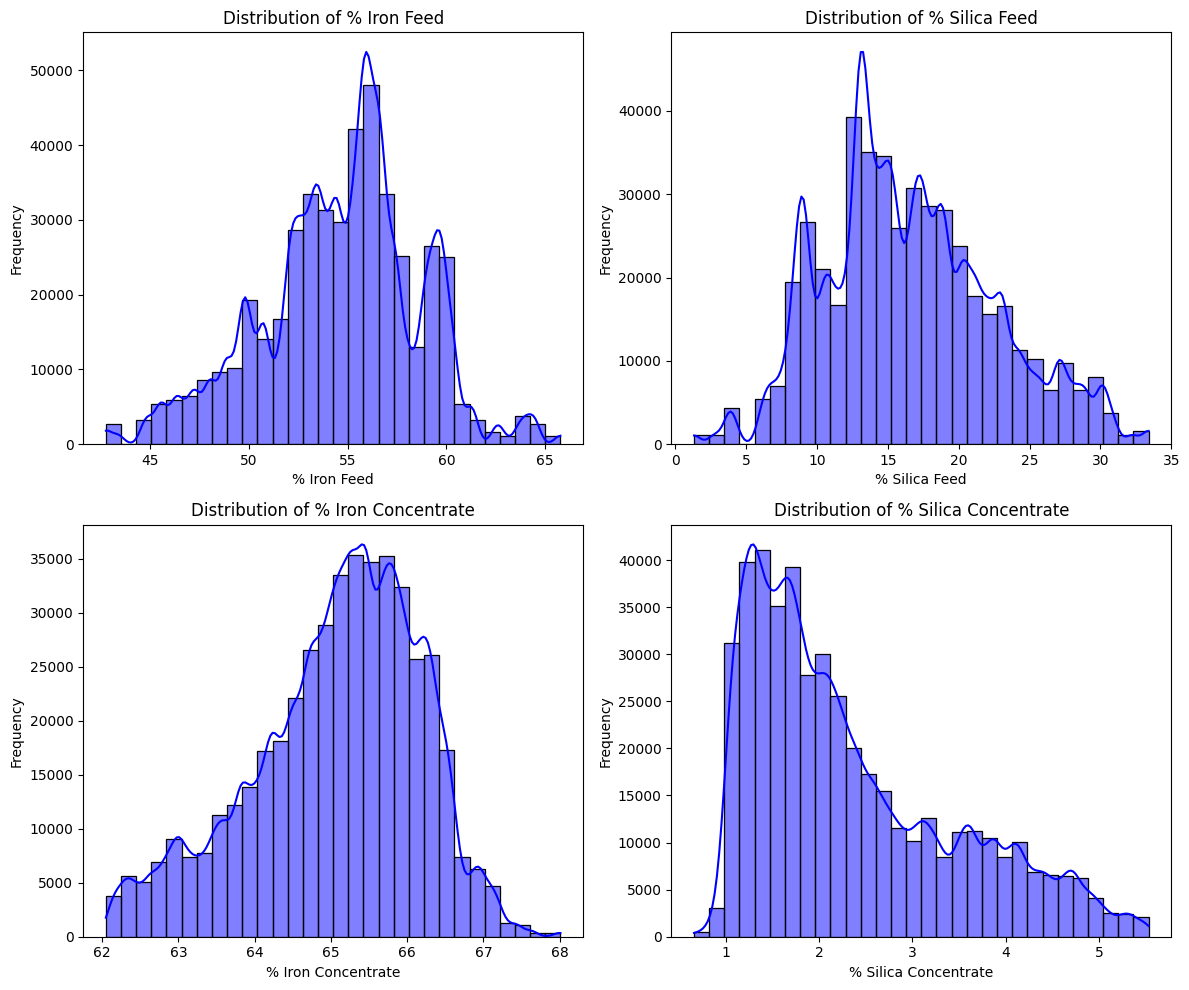

In [45]:
df = df_cleaned

# Define columns to plot (choose any 4 numeric columns)
columns_to_plot = ['% Iron Feed', '% Silica Feed', '% Iron Concentrate', '% Silica Concentrate']

# Create a 2x2 layout for the plots
fig, axes = plt.subplots(2, 2, figsize=(12, 10))  # 2x2 grid

# Flatten the axes array for easy iteration
axes = axes.flatten()

# Plot each column in the 2x2 layout
for i, col in enumerate(columns_to_plot):
    sns.histplot(df[col].dropna(), kde=True, bins=30, ax=axes[i], color='blue')
    axes[i].set_title(f"Distribution of {col}", fontsize=12)
    axes[i].set_xlabel(col, fontsize=10)
    axes[i].set_ylabel("Frequency", fontsize=10)

# Adjust layout to prevent overlap
plt.tight_layout()
plt.show()

#### <b>D. Menghitung Ulang Korelasi Antar Variabel </b>

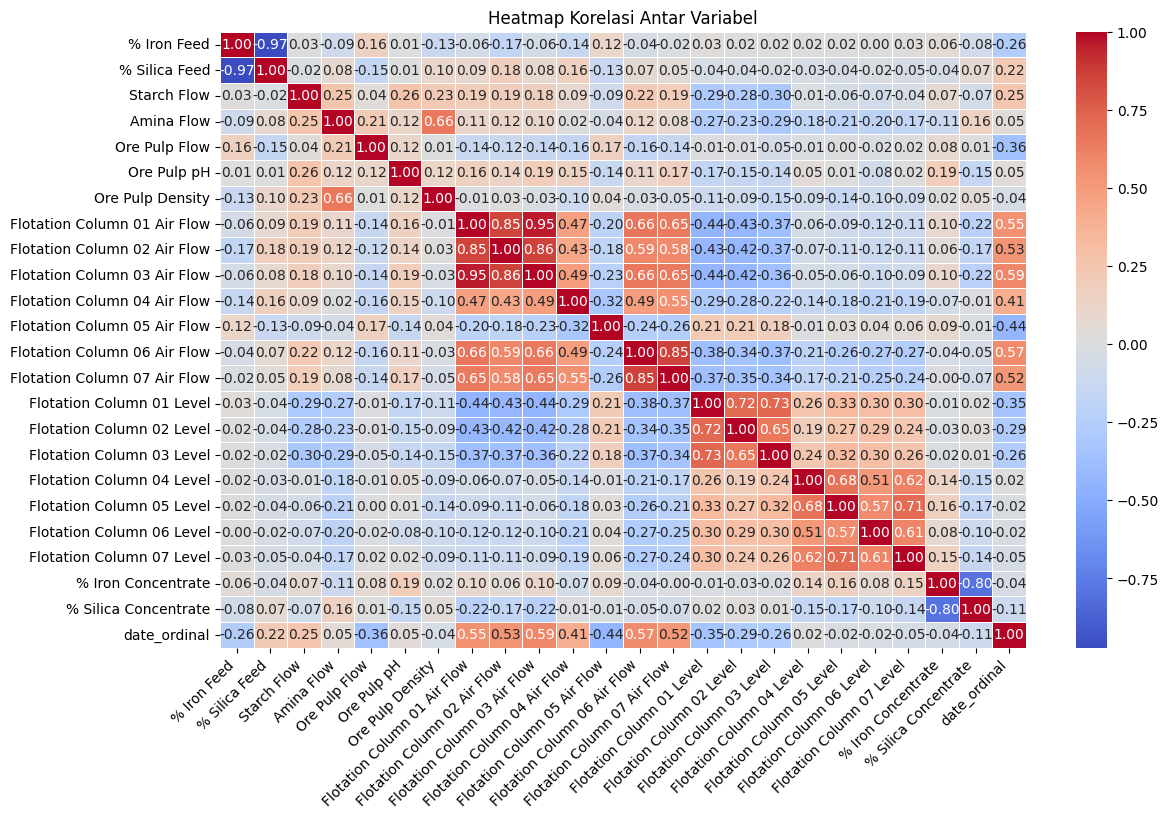

In [62]:
# Ensure 'date' is in datetime format
df['date'] = pd.to_datetime(df['date'])

# Add numeric representations of the date
df['date_ordinal'] = df['date'].map(lambda x: x.toordinal())  # Days since year 1

# Select only numeric columns for correlation
numeric_columns = df.select_dtypes(include=['number'])

# Hitung matriks korelasi
correlation_matrix = numeric_columns.corr()

# Plot heatmap
plt.figure(figsize=(13, 8))  # Sesuaikan ukuran jika diperlukan
sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.xticks(rotation=45, ha='right')  # Rotate x-axis labels 45 degrees, align right
plt.yticks(rotation=0)
plt.title("Heatmap Korelasi Antar Variabel")
plt.show()
df = df.drop(columns=['date_ordinal'])

___

### <b>#6: Feature Engineering </b>

#### <b>A. Membangi Data Train, Data Test, dan Data Validasi </b>

In [79]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import AdaBoostRegressor
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.tree import DecisionTreeRegressor

# Drop kolom yang tidak digunakan
columns_to_drop = ['date', '% Silica Concentrate']
data = df.drop(columns=[col for col in columns_to_drop if col in df.columns])

# Memisahkan fitur (X) dan target (y)
X = data.drop(columns=['% Iron Concentrate'])  # Ganti dengan nama kolom target yang tepat
y = data['% Iron Concentrate']

# Membagi dataset menjadi training dan testing set
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3, random_state=42)  # 70% train, 30% lainnya
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)  # 15% val, 15% test

#### <b>B. Standarization </b>

In [64]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
X_val_scaled = scaler.transform(X_val)

#### <b>C. Feature Importance via Coefficient Ridge Model </b>

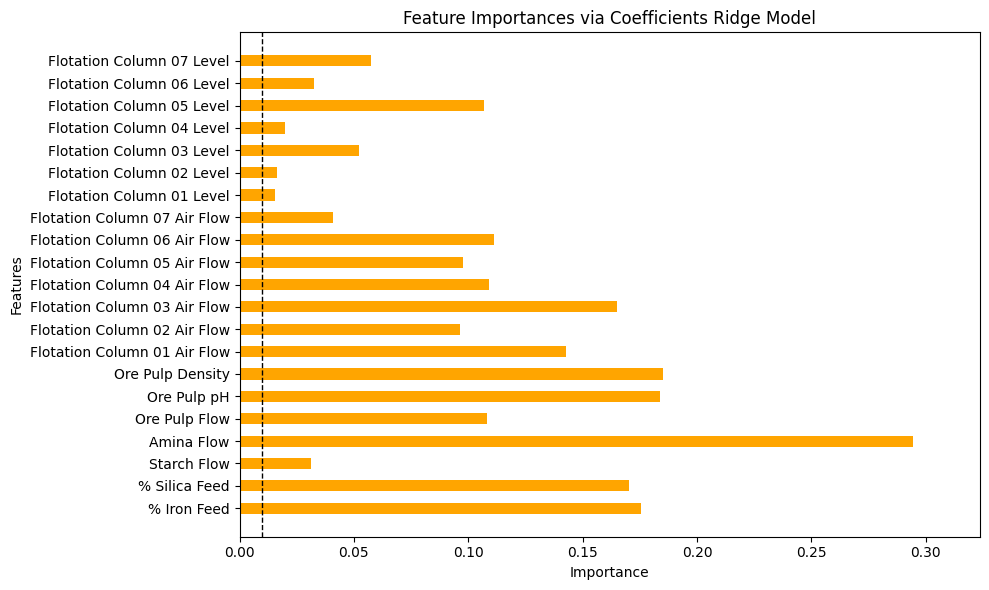

In [78]:
from sklearn.linear_model import RidgeCV

# Model RidgeCV dengan alphas tertentu
ridge = RidgeCV(alphas=np.logspace(-3, 3, num=5)).fit(X_train, y_train)

# Menghitung feature importance berdasarkan absolut nilai koefisien
importance = np.abs(ridge.coef_)

# Nama fitur
if isinstance(X, pd.DataFrame):  # Jika X adalah DataFrame
    feature_names = X.columns
else:  # Jika X adalah array numpy
    feature_names = [f"Feature {i}" for i in range(X.shape[1])]

# Membuat plot dengan bar horizontal
plt.figure(figsize=(10, 6))
plt.barh(y=feature_names, width=importance, color='orange', height=0.5)
plt.axvline(x=0.01, color='black', linestyle='--', linewidth=1, label='Threshold (0.01)')  # Garis vertikal
plt.title("Feature Importances via Coefficients Ridge Model")
plt.xlabel("Importance")
plt.ylabel("Features")
plt.xlim(0, max(importance) * 1.1)  # Menyesuaikan batas x agar proporsional
plt.tight_layout()
plt.show()

___

### <b>#7: Model Building </b>

#### <b>A. Adaboost Regressor - Decission Tree</b>

#### <u> Train Model Metode Train Validation Split</u>

In [ ]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import AdaBoostRegressor
from sklearn.metrics import mean_squared_error, r2_score

# Inisialisasi list untuk menyimpan error
mse_values_test = []
mse_values_validation = []
r2_values_test = []
r2_values_validation = []

# Iterasi n_estimators dari 1 hingga 10
for n in range(1, 11):
    # Membuat model AdaBoost Regressor
    base_estimator = DecisionTreeRegressor(max_depth=50)
    adaboost_model = AdaBoostRegressor(base_estimator=base_estimator, n_estimators=n, learning_rate=1, random_state=42)
    
    # Melatih model
    adaboost_model.fit(X_train_scaled, y_train)
    
    # Memprediksi data testing
    y_pred_test = adaboost_model.predict(X_test_scaled)
    y_pred_validation = adaboost_model.predict(X_val_scaled)

    # Menghitung MSE
    mse_test = mean_squared_error(y_test, y_pred_test)
    mse_validation = mean_squared_error(y_val, y_pred_validation)
    r2_sc_test = r2_score(y_test, y_pred_test)
    r2_sc_validation = r2_score(y_val, y_pred_validation)
    mse_values_test.append(mse_test)
    mse_values_validation.append(mse_validation)
    r2_values_test.append(r2_sc_test)
    r2_values_validation.append(r2_sc_validation)

#### <u> Loss Pelatihan</u>

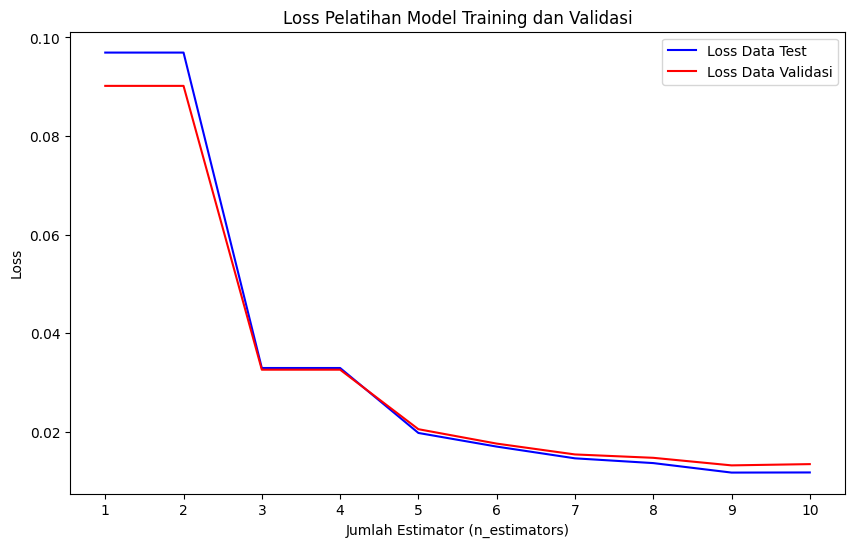

In [66]:
# Plot perkembangan error (MSE) terhadap n_estimators
plt.figure(figsize=(10, 6))
plt.plot(range(1, 11), mse_values_test, linestyle='-', color='b', label='Loss Data Test')
plt.plot(range(1, 11), mse_values_validation, linestyle='-', color='r', label='Loss Data Validasi')
plt.title('Loss Pelatihan Model Training dan Validasi')
plt.xlabel('Jumlah Estimator (n_estimators)')
plt.ylabel('Loss')
plt.xticks(range(1, 11))
plt.legend()
plt.show() 

#### <u> Feature Importance Mean Decrease in Impurity (MDI) untuk Pemodelan AdaBoost Regression</u>

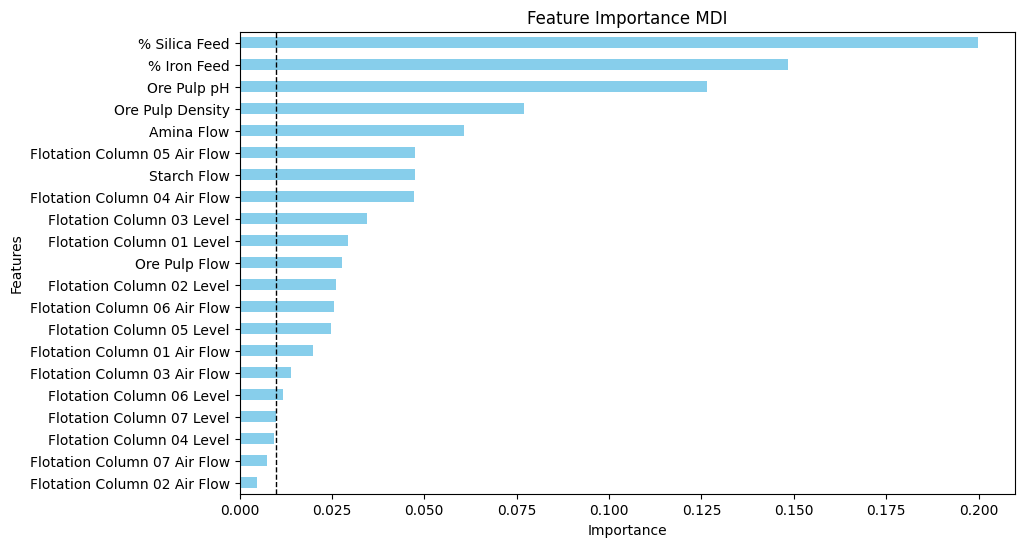

In [67]:
# Feature importance
feature_names = X.columns  # Nama fitur dari DataFrame X
feature_importances = pd.Series(
    adaboost_model.feature_importances_, index=feature_names
).sort_values(ascending=True)

feature_importances.sort_values().plot(kind='barh', figsize=(10, 6), color='skyblue')
plt.axvline(x=0.01, color='black', linestyle='--', linewidth=1, label='Threshold (0.01)')  # Garis vertikal
plt.title("Feature Importance MDI")
plt.xlabel("Importance")
plt.ylabel("Features")
plt.show()

#### <u> Evaluasi Model </u>

In [ ]:
print("Adaboost Regression - Decision Tree")
print(40*'-')
print('Test Metrix')
print("  MSE:", mse_values_test[1])
print("  R² :", r2_values_test[1])
print('Validation Metrix')
print("  MSE:", mse_values_validation[1])
print("  R² :", r2_values_validation[1])

Adaboost Regression - Decision Tree
----------------------------------------
Test Metrix
  MSE: 0.09017140130965119
  R² : 0.9274182972643217
Validation Metrix
  MSE: 0.09692408076046911
  R² : 0.9214174794443186


#### <b>B. KNN</b>

#### <u> Train Model </u>

In [70]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsRegressor

X_train = X_train_scaled
X_test = X_test_scaled

# Define a function for model training and evaluation
def train_and_evaluate(model, X_train, X_test, y_train, y_test):
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    return mae, mse, r2, y_pred

# Initialize models
models = {
    "KNN Regressor": KNeighborsRegressor(n_neighbors=5, algorithm='auto'),
}

# Evaluate models
results = {}
for name, model in models.items():
    print(f"Training {name}")
    mae, mse, r2, y_pred = train_and_evaluate(model, X_train, X_test, y_train, y_test)
    results[name] = {"MAE": mae, "MSE": mse, "R²": r2}

Training KNN Regressor


#### <u> Membandingkan Hasil Prediksi dan Data Aktual </u>

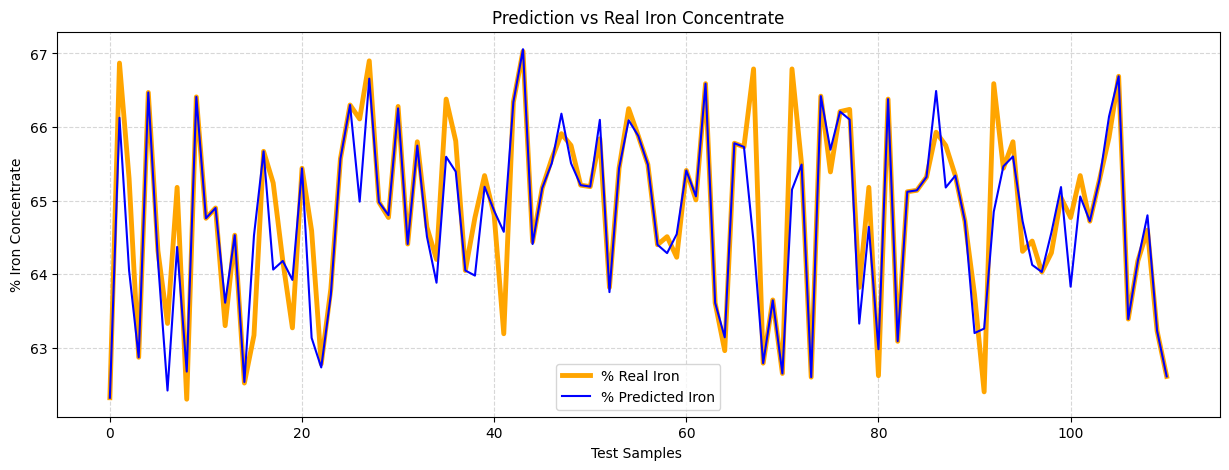

In [71]:
import matplotlib.pyplot as plt
import numpy as np

# Menentukan indeks subset secara eksplisit 
subset_indices = np.arange(0, len(y_test), step=1000) 
subset_indices = np.sort(subset_indices)  # Pastikan tetap terurut

# Membuat plot dengan subset data
plt.figure(figsize=(15, 5))
test_samples_subset = np.arange(len(subset_indices))  # Index untuk sampel subset

# Plot real iron
plt.plot(test_samples_subset, y_test.values[subset_indices], label='% Real Iron', color='orange', linewidth=3.5)

# Plot predicted iron
plt.plot(test_samples_subset, y_pred[subset_indices], label='% Predicted Iron', color='blue', linewidth=1.5)

# Menambahkan label, legenda, dan judul
plt.xlabel('Test Samples ')
plt.ylabel('% Iron Concentrate')
plt.legend()
plt.title('Prediction vs Real Iron Concentrate')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

#### <u> Evaluasi Model </u>

In [72]:
# Evaluasi pada data latih dan data uji
for name, model in models.items():
    print(f"{name}")

    # Prediksi pada data latih
    y_train_pred = model.predict(X_train)
    mae_train = mean_absolute_error(y_train, y_train_pred)
    mse_train = mean_squared_error(y_train, y_train_pred)
    r2_train = r2_score(y_train, y_train_pred)

    # Prediksi pada data uji
    y_test_pred = model.predict(X_test)
    mae_test = mean_absolute_error(y_test, y_test_pred)
    mse_test = mean_squared_error(y_test, y_test_pred)
    r2_test = r2_score(y_test, y_test_pred)

    # Tampilkan hasil
    print("Train Metrics:")
    print(f"  MAE: {mae_train:.4f}")
    print(f"  MSE: {mse_train:.4f}")
    print(f"  R² : {r2_train:.4f}")
    print("Test Metrics:")
    print(f"  MAE: {mae_test:.4f}")
    print(f"  MSE: {mse_test:.4f}")
    print(f"  R² : {r2_test:.4f}")

KNN Regressor
Train Metrics:
  MAE: 0.1628
  MSE: 0.1111
  R² : 0.9113
Test Metrics:
  MAE: 0.2180
  MSE: 0.1782
  R² : 0.8575
